# Sarcasm Detection in News Headlines
## Part III – Language Task | 6CS012 AI & ML
**Dataset:** sarcastic_headlines.csv (~28,000 headlines)
**Task:** Binary Classification — Sarcastic (1) vs Not Sarcastic (0)
**Models:** SimpleRNN | LSTM | LSTM + GloVe Pretrained Embeddings
**GUI:** Gradio real-time prediction interface

In [20]:

!pip install contractions wordcloud gradio gensim --quiet

In [21]:
import os, re, random, time, warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import contractions
from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, confusion_matrix,
                              classification_report, ConfusionMatrixDisplay)

import tensorflow as tf
from tensorflow.keras import Input
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Embedding, SimpleRNN, LSTM,
                                      Dense, Dropout, BatchNormalization)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import gensim.downloader as api


import gradio as gr

warnings.filterwarnings('ignore')
tf.get_logger().setLevel('ERROR')

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)


nltk.download('wordnet',    quiet=True)
nltk.download('omw-1.4',   quiet=True)
nltk.download('stopwords', quiet=True)


plt.rcParams.update({
    'figure.facecolor' : 'white',
    'axes.facecolor'   : '#f8f9fa',
    'axes.grid'        : True,
    'grid.alpha'       : 0.4,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'font.size'        : 11
})

print(f'TensorFlow : {tf.__version__}')
print(f'GPU        : {tf.config.list_physical_devices("GPU")}')
print(f'Seed       : {SEED}')
print('All libraries loaded successfully!')

TensorFlow : 2.20.0
GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Seed       : 42
All libraries loaded successfully!


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
DATASET OVERVIEW
Shape         : (28619, 2)
Columns       : ['headline', 'is_sarcastic']
Missing values:
headline        0
is_sarcastic    0
dtype: int64

Total rows after cleaning: 28619

Sample rows:


,headline,is_sarcastic
0,thirtysomething scientists unveil doomsday clo...,1
1,dem rep. totally nails why congress is falling...,0
2,eat your veggies: 9 deliciously different recipes,0
3,inclement weather prevents liar from getting t...,1
4,mother comes pretty close to using word 'strea...,1



Class Distribution:
  Not Sarcastic   :  14985  (52.4%)
  Sarcastic       :  13634  (47.6%)


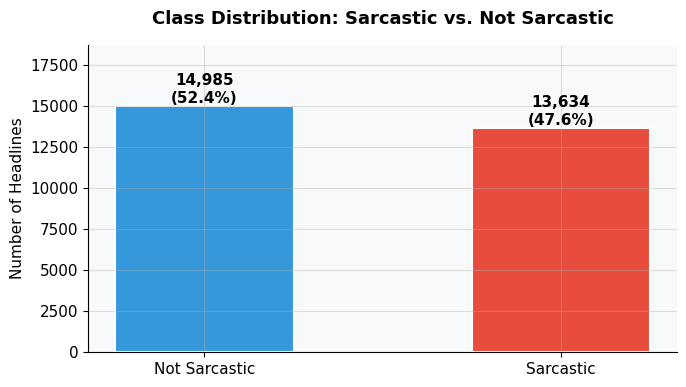

In [8]:

from google.colab import drive
drive.mount('/content/drive')

DATA_PATH = '/content/drive/MyDrive/AI and Machine Learning/sarcastic_headlines.csv'
df = pd.read_csv(DATA_PATH)

print('='*50)
print('DATASET OVERVIEW')
print('='*50)
print(f'Shape         : {df.shape}')
print(f'Columns       : {df.columns.tolist()}')
print(f'Missing values:\n{df.isnull().sum()}')
print()


df = df.dropna(subset=['headline', 'is_sarcastic']).reset_index(drop=True)
print(f'Total rows after cleaning: {len(df)}')
print()
print('Sample rows:')
display(df.head(5))


counts    = df['is_sarcastic'].value_counts().sort_index()
total     = len(df)
label_map = {0: 'Not Sarcastic', 1: 'Sarcastic'}

print('\nClass Distribution:')
for cls, cnt in counts.items():
    print(f'  {label_map[cls]:<16}: {cnt:>6}  ({cnt/total*100:.1f}%)')

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(
    [label_map[0], label_map[1]],
    [counts[0], counts[1]],
    color=['#3498db', '#e74c3c'],
    edgecolor='white', linewidth=1.5, width=0.5
)
for bar, (cls, cnt) in zip(bars, counts.items()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 40,
        f'{cnt:,}\n({cnt/total*100:.1f}%)',
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )
ax.set_title('Class Distribution: Sarcastic vs. Not Sarcastic',
             fontsize=13, fontweight='bold', pad=15)
ax.set_ylabel('Number of Headlines')
ax.set_ylim(0, max(counts) * 1.25)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
_lemmatizer  = WordNetLemmatizer()
_stop_words  = set(stopwords.words('english'))

def preprocess_text(text):
    """
    Clean a single headline.
    Steps:
      1. Lowercase
      2. Expand contractions  (don't → do not)
      3. Remove URLs
      4. Remove @mentions
      5. Remove # symbol (keep the word)
      6. Remove digits
      7. Remove punctuation / special characters
      8. Remove stopwords
      9. Lemmatize tokens
    """
    text = str(text).lower()
    text = contractions.fix(text)
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#', '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = text.split()
    tokens = [t for t in tokens if t not in _stop_words]
    tokens = [_lemmatizer.lemmatize(t) for t in tokens]
    result = ' '.join(tokens).strip()
    return result if result else 'unknown'


print('Preprocessing headlines...')
df['cleaned_text'] = df['headline'].apply(preprocess_text)
print(f'Done! {len(df)} headlines preprocessed.')

print('\nBefore / After Examples:')
print('-' * 70)
for idx in df.sample(4, random_state=SEED).index:
    print(f'Original : {df.loc[idx, "headline"]}')
    print(f'Cleaned  : {df.loc[idx, "cleaned_text"]}')
    print()

orig_len    = df['headline'].str.split().str.len()
cleaned_len = df['cleaned_text'].str.split().str.len()
print(f'Avg original length : {orig_len.mean():.1f} tokens')
print(f'Avg cleaned length  : {cleaned_len.mean():.1f} tokens')
print(f'Length reduction    : {(1 - cleaned_len.mean()/orig_len.mean())*100:.1f}%')

Preprocessing headlines...
Done! 28619 headlines preprocessed.

Before / After Examples:
----------------------------------------------------------------------
Original : states slow to shut down weak teacher education programs
Cleaned  : state slow shut weak teacher education program

Original : drone places fresh kill on steps of white house
Cleaned  : drone place fresh kill step white house

Original : report: majority of instances of people getting lives back on track occur immediately after visit to buffalo wild wings
Cleaned  : report majority instance people getting life back track occur immediately visit buffalo wild wing

Original : sole remaining lung filled with rich, satisfying flavor
Cleaned  : sole remaining lung filled rich satisfying flavor

Avg original length : 10.0 tokens
Avg cleaned length  : 7.1 tokens
Length reduction    : 29.6%


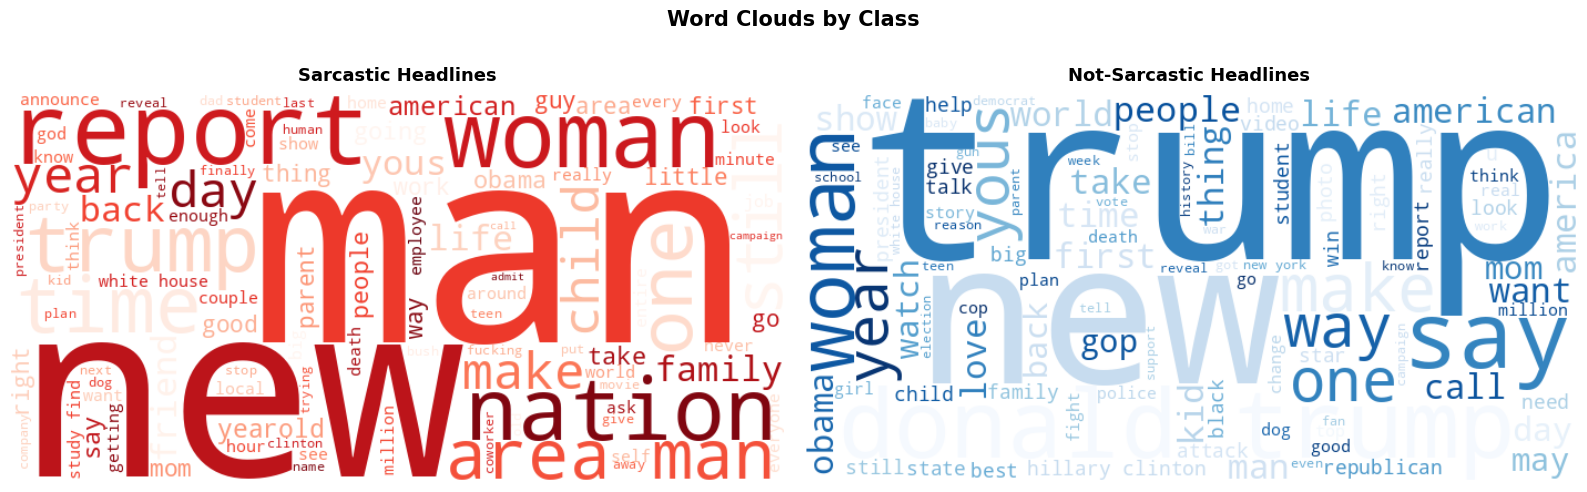

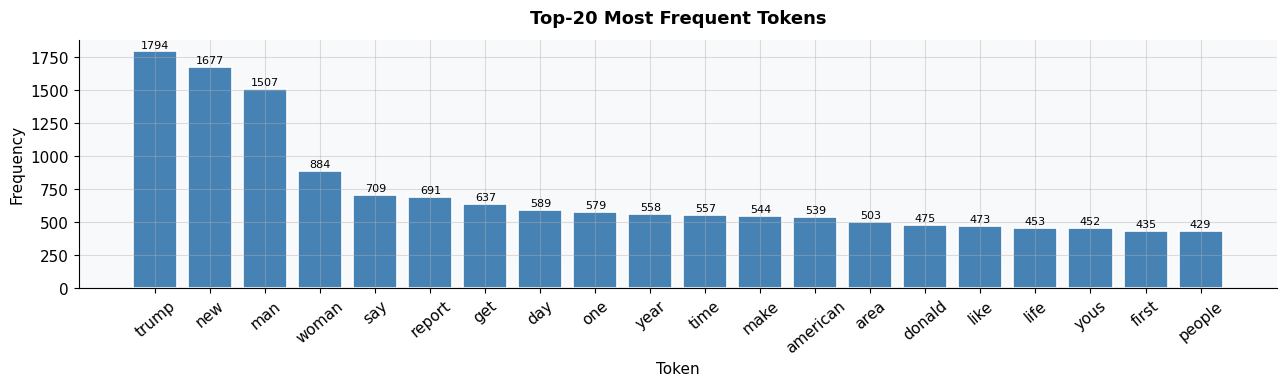

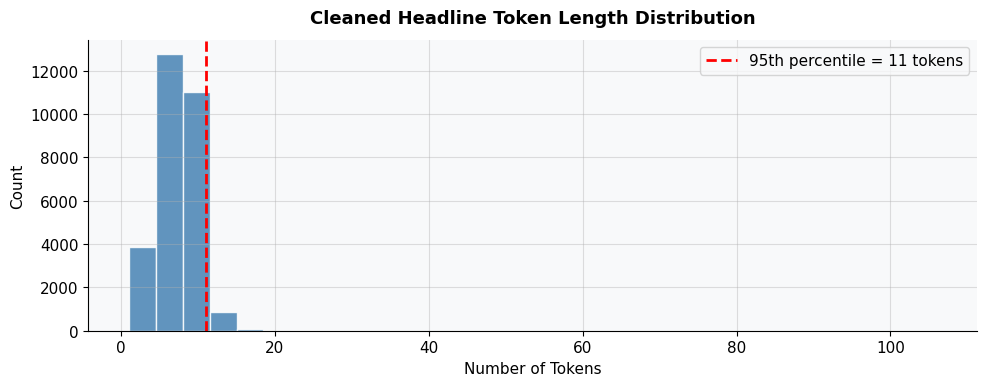

Padding length chosen (95th percentile): 11 tokens


In [10]:

sarc_text     = ' '.join(df[df['is_sarcastic'] == 1]['cleaned_text'])
not_sarc_text = ' '.join(df[df['is_sarcastic'] == 0]['cleaned_text'])
all_text      = ' '.join(df['cleaned_text'])


fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Word Clouds by Class', fontsize=15, fontweight='bold', y=1.02)

wc_sarc = WordCloud(width=700, height=350, background_color='white',
                    colormap='Reds', max_words=100).generate(sarc_text)
wc_not  = WordCloud(width=700, height=350, background_color='white',
                    colormap='Blues', max_words=100).generate(not_sarc_text)

for ax, wc, title in zip(axes,
                          [wc_sarc, wc_not],
                          ['Sarcastic Headlines', 'Not-Sarcastic Headlines']):
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(title, fontsize=13, fontweight='bold', pad=10)
    ax.axis('off')

plt.tight_layout()
plt.savefig('word_clouds.png', dpi=150, bbox_inches='tight')
plt.show()

top20 = Counter(all_text.split()).most_common(20)
words, freqs = zip(*top20)

fig, ax = plt.subplots(figsize=(13, 4))
bars = ax.bar(words, freqs, color='steelblue', edgecolor='white', linewidth=1.2)
ax.set_title('Top-20 Most Frequent Tokens', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Token')
ax.set_ylabel('Frequency')
ax.tick_params(axis='x', rotation=40)
for bar, freq in zip(bars, freqs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
            str(freq), ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig('top20_tokens.png', dpi=150, bbox_inches='tight')
plt.show()

p95 = int(np.percentile(cleaned_len, 95))

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(cleaned_len, bins=30, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(x=p95, color='red', linestyle='--', linewidth=2,
            label=f'95th percentile = {p95} tokens')
ax.set_title('Cleaned Headline Token Length Distribution',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Number of Tokens')
ax.set_ylabel('Count')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Padding length chosen (95th percentile): {p95} tokens')

In [11]:


X = df['cleaned_text'].values
y = df['is_sarcastic'].values

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)


tokenizer = Tokenizer(num_words=5000, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train_raw)
vocab_size = len(tokenizer.word_index)

X_train_seq = tokenizer.texts_to_sequences(X_train_raw)
X_test_seq  = tokenizer.texts_to_sequences(X_test_raw)


max_len = int(np.percentile([len(s) for s in X_train_seq], 95))

X_train = pad_sequences(X_train_seq, maxlen=max_len, padding='post', truncating='post')
X_test  = pad_sequences(X_test_seq,  maxlen=max_len, padding='post', truncating='post')
y_train = np.array(y_train)
y_test  = np.array(y_test)


results = {}

print('='*45)
print('TOKENISATION SUMMARY')
print('='*45)
print(f'Vocabulary size   : {vocab_size:,}')
print(f'Max sequence len  : {max_len}')
print(f'X_train shape     : {X_train.shape}')
print(f'X_test  shape     : {X_test.shape}')
train_dist = dict(zip(*np.unique(y_train, return_counts=True)))
test_dist  = dict(zip(*np.unique(y_test,  return_counts=True)))
print(f'Train class dist  : {train_dist}')
print(f'Test  class dist  : {test_dist}')

TOKENISATION SUMMARY
Vocabulary size   : 22,570
Max sequence len  : 11
X_train shape     : (22895, 11)
X_test  shape     : (5724, 11)
Train class dist  : {np.int64(0): np.int64(11988), np.int64(1): np.int64(10907)}
Test  class dist  : {np.int64(0): np.int64(2997), np.int64(1): np.int64(2727)}


In [12]:


def get_callbacks():
    """Standard callbacks for all models."""
    return [
        EarlyStopping(
            monitor='val_loss',
            patience=5,
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=3,
            min_lr=1e-6,
            verbose=1
        )
    ]


def plot_training_history(history, model_name, color='steelblue'):
    """
    Plot training vs validation accuracy AND loss side by side.
    Solid line = training | Dashed line = validation
    """
    epochs = range(1, len(history.history['accuracy']) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'{model_name} — Training History',
                 fontsize=14, fontweight='bold', y=1.02)


    ax1.plot(epochs, history.history['accuracy'],
             color=color, lw=2.5, marker='o', markersize=4, label='Train Accuracy')
    ax1.plot(epochs, history.history['val_accuracy'],
             color=color, lw=2.5, marker='s', markersize=4,
             linestyle='--', label='Validation Accuracy')
    ax1.set_title('Accuracy over Epochs', fontweight='bold')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.set_ylim(0.40, 1.02)
    ax1.legend(loc='lower right', fontsize=10)
    ax1.grid(True, alpha=0.4)


    ax2.plot(epochs, history.history['loss'],
             color='tomato', lw=2.5, marker='o', markersize=4, label='Train Loss')
    ax2.plot(epochs, history.history['val_loss'],
             color='tomato', lw=2.5, marker='s', markersize=4,
             linestyle='--', label='Validation Loss')
    ax2.set_title('Loss over Epochs', fontweight='bold')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend(loc='upper right', fontsize=10)
    ax2.grid(True, alpha=0.4)

    plt.tight_layout()
    safe_name = model_name.replace(' ', '_').replace('+', 'plus')
    plt.savefig(f'{safe_name}_history.png', dpi=150, bbox_inches='tight')
    plt.show()


def evaluate_model(model, X_test, y_test, model_name, history):
    """
    Full evaluation:
      - Test accuracy
      - Overfitting gap check
      - Confusion matrix (clean heatmap)
      - Classification report
    Returns dict with accuracy, predictions, confusion matrix.
    """
    y_pred_prob = model.predict(X_test, verbose=0).flatten()
    y_pred      = (y_pred_prob >= 0.5).astype(int)
    acc         = accuracy_score(y_test, y_pred)

    print(f'\n{"="*55}')
    print(f'{model_name}')
    print(f'{"="*55}')
    print(f'Test Accuracy : {acc:.4f}  ({acc*100:.2f}%)')


    best_epoch = int(np.argmin(history.history['val_loss']))
    train_acc  = history.history['accuracy'][best_epoch]
    gap        = train_acc - acc
    print(f'Best Epoch    : {best_epoch + 1}')
    print(f'Train Acc @ best epoch: {train_acc:.4f}')
    if gap > 0.08:
        print(f'⚠️  Overfitting detected — gap: {gap:.4f}')
    else:
        print(f'✅  Generalising well   — gap: {gap:.4f}')


    cm     = confusion_matrix(y_test, y_pred)
    labels = ['Not Sarcastic', 'Sarcastic']

    fig, ax = plt.subplots(figsize=(6, 5))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(ax=ax, cmap='Blues', colorbar=True, values_format='d')
    ax.set_title(f'{model_name}\nConfusion Matrix',
                 fontweight='bold', fontsize=12, pad=12)
    plt.xticks(rotation=15)
    plt.tight_layout()
    safe_name = model_name.replace(' ', '_').replace('+', 'plus')
    plt.savefig(f'{safe_name}_confusion_matrix.png', dpi=150, bbox_inches='tight')
    plt.show()


    report = classification_report(
        y_test, y_pred,
        target_names=['Not Sarcastic', 'Sarcastic'],
        digits=4
    )
    print('\nClassification Report:')
    print(report)

    return {'accuracy': acc, 'y_pred': y_pred, 'y_pred_prob': y_pred_prob, 'cm': cm}


print('Helper functions defined.')

Helper functions defined.


Model: "Model_1_SimpleRNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 11, 16)         │        80,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 11, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 32)             │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 81,617 (318.82 KB)

 Trainable params: 81,617 (318.82 KB)

 Non-trainable params: 0 (0.00 B)


Training Model 1 — Simple RNN...
Epoch 1/30
322/322 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.6423 - loss: 0.6185 - val_accuracy: 0.7428 - val_loss: 0.5166 - learning_rate: 3.0000e-04
Epoch 2/30
322/322 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7858 - loss: 0.4563 - val_accuracy: 0.7817 - val_loss: 0.4571 - learning_rate: 3.0000e-04
Epoch 3/30
322/322 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8274 - loss: 0.3869 - val_accuracy: 0.7908 - val_loss: 0.4405 - learning_rate: 3.0000e-04
Epoch 4/30
322/322 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8514 - loss: 0.3460 - val_accuracy: 0.7983 - val_loss: 0.4338 - learning_rate: 3.0000e-04
Epoch 5/30
322/322 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8668 - loss: 0.3136 - val_accuracy: 0.8017 - val_loss: 0.4393 - learning_rate: 3.0000e-04
Epoch 6/30
322/322 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8778 - loss: 0.2875 - val_accuracy: 0.8031 - val_loss: 0.4478 - learning_rate: 3.0000e-04
Epoch 7/30
321/322 ━━━━━━━━━━

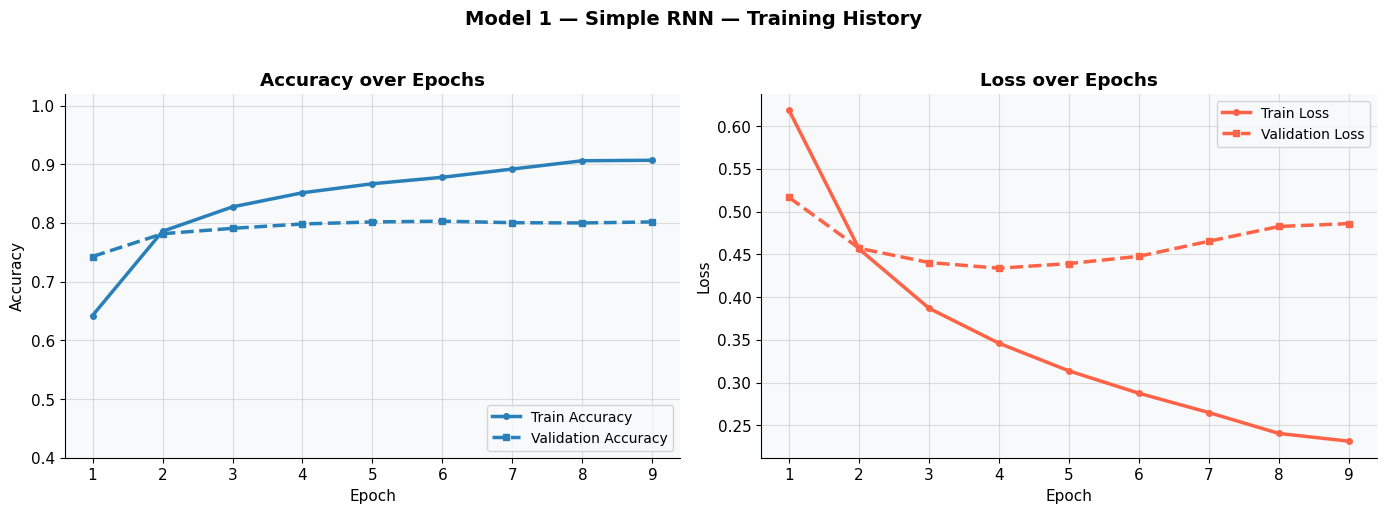


Model 1 — Simple RNN
Test Accuracy : 0.7802  (78.02%)
Best Epoch    : 4
Train Acc @ best epoch: 0.8514
✅  Generalising well   — gap: 0.0712


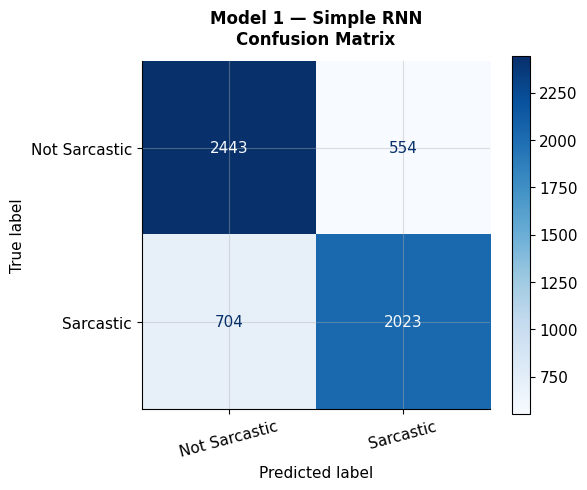


Classification Report:
               precision    recall  f1-score   support

Not Sarcastic     0.7763    0.8151    0.7952      2997
    Sarcastic     0.7850    0.7418    0.7628      2727

     accuracy                         0.7802      5724
    macro avg     0.7807    0.7785    0.7790      5724
 weighted avg     0.7805    0.7802    0.7798      5724



In [13]:


EMB_DIM_RNN =
VOCAB_CAP   = min(vocab_size + 1, 5001)

rnn_model = Sequential([
    Input(shape=(max_len,)),


    Embedding(input_dim=VOCAB_CAP, output_dim=EMB_DIM_RNN),

    Dropout(0.3),


    SimpleRNN(32),

    Dropout(0.3),


    Dense(1, activation='sigmoid')
], name='Model_1_SimpleRNN')

rnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
rnn_model.summary()

print('\nTraining Model 1 — Simple RNN...')
t0 = time.time()

rnn_history = rnn_model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=64,
    validation_split=0.1,
    callbacks=get_callbacks(),
    verbose=1
)

rnn_time = (time.time() - t0) / 60
print(f'\nTraining Time : {rnn_time:.1f} min')
print(f'Epochs run    : {len(rnn_history.history["accuracy"])}')

plot_training_history(rnn_history, 'Model 1 — Simple RNN', color='#2980b9')

results['Simple RNN'] = evaluate_model(
    rnn_model, X_test, y_test,
    'Model 1 — Simple RNN', rnn_history
)

Model: "Model_2_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 11, 16)         │        80,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 11, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 32)             │         6,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 86,321 (337.19 KB)

 Trainable params: 86,321 (337.19 KB)

 Non-trainable params: 0 (0.00 B)


Training Model 2 — LSTM...
Epoch 1/30
322/322 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.6242 - loss: 0.6315 - val_accuracy: 0.7441 - val_loss: 0.5244 - learning_rate: 3.0000e-04
Epoch 2/30
322/322 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.7882 - loss: 0.4581 - val_accuracy: 0.7808 - val_loss: 0.4718 - learning_rate: 3.0000e-04
Epoch 3/30
322/322 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8227 - loss: 0.3980 - val_accuracy: 0.7895 - val_loss: 0.4530 - learning_rate: 3.0000e-04
Epoch 4/30
322/322 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8427 - loss: 0.3657 - val_accuracy: 0.7926 - val_loss: 0.4529 - learning_rate: 3.0000e-04
Epoch 5/30
322/322 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8545 - loss: 0.3427 - val_accuracy: 0.7948 - val_loss: 0.4574 - learning_rate: 3.0000e-04
Epoch 6/30
322/322 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8588 - loss: 0.3319 - val_accuracy: 0.7847 - val_loss: 0.4670 - learning_rate: 3.0000e-04
Epoch 7/30
316/322 ━━━━━━━━━━━━━━━━

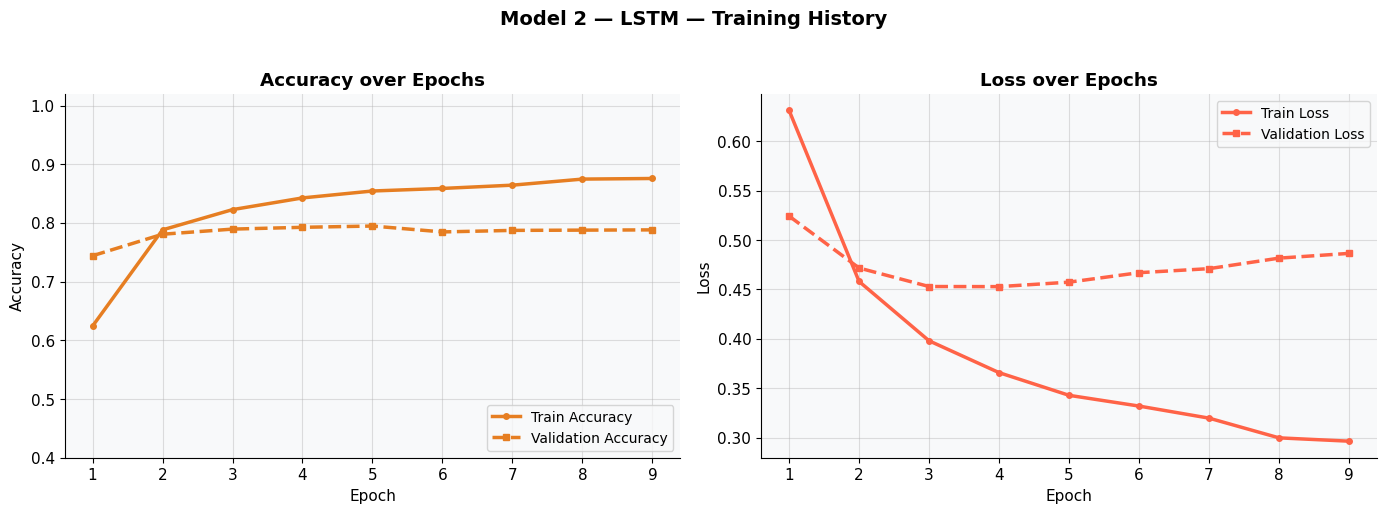


Model 2 — LSTM
Test Accuracy : 0.7809  (78.09%)
Best Epoch    : 4
Train Acc @ best epoch: 0.8427
✅  Generalising well   — gap: 0.0617


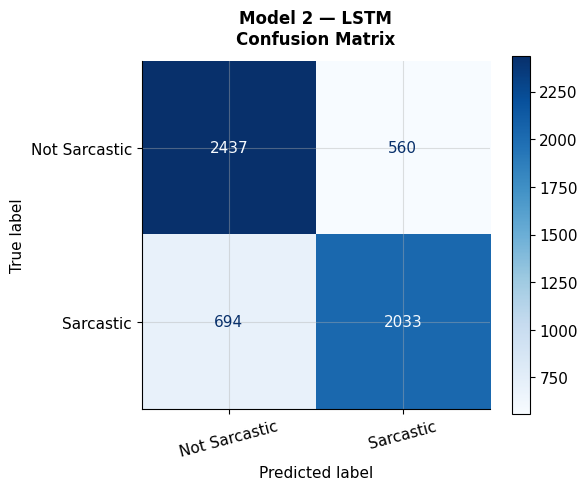


Classification Report:
               precision    recall  f1-score   support

Not Sarcastic     0.7783    0.8131    0.7954      2997
    Sarcastic     0.7840    0.7455    0.7643      2727

     accuracy                         0.7809      5724
    macro avg     0.7812    0.7793    0.7798      5724
 weighted avg     0.7811    0.7809    0.7806      5724



In [14]:
EMB_DIM_LSTM = 16

lstm_model = Sequential([
    Input(shape=(max_len,)),


    Embedding(input_dim=VOCAB_CAP, output_dim=EMB_DIM_LSTM),

    Dropout(0.3),


    LSTM(32),


    Dropout(0.3),


    Dense(1, activation='sigmoid')
], name='Model_2_LSTM')

lstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
lstm_model.summary()

print('\nTraining Model 2 — LSTM...')
t0 = time.time()

lstm_history = lstm_model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=64,
    validation_split=0.1,
    callbacks=get_callbacks(),
    verbose=1
)

lstm_time = (time.time() - t0) / 60
print(f'\nTraining Time : {lstm_time:.1f} min')
print(f'Epochs run    : {len(lstm_history.history["accuracy"])}')

plot_training_history(lstm_history, 'Model 2 — LSTM', color='#e67e22')

results['LSTM'] = evaluate_model(
    lstm_model, X_test, y_test,
    'Model 2 — LSTM', lstm_history
)

Loading GloVe Twitter 100-dim embeddings...
(First run downloads ~200MB; cached on subsequent runs)
[==================================================] 100.0% 387.1/387.1MB downloaded
GloVe loaded — vocabulary: 1,193,514 words
Embedding matrix shape : (22571, 100)
GloVe coverage         : 19589/22570 (86.8%)


Model: "Model_3_LSTM_GloVe"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 11, 100)        │     2,257,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 11, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        42,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,301,709 (8.78 MB)

 Trainable params: 44,481 (173.75 KB)

 Non-trainable params: 2,257,228 (8.61 MB)


Training Model 3 — LSTM + GloVe...
Epoch 1/25
322/322 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.6199 - loss: 0.6769 - val_accuracy: 0.6891 - val_loss: 0.6161 - learning_rate: 0.0010
Epoch 2/25
322/322 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6887 - loss: 0.5923 - val_accuracy: 0.7402 - val_loss: 0.5226 - learning_rate: 0.0010
Epoch 3/25
322/322 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.7192 - loss: 0.5561 - val_accuracy: 0.7524 - val_loss: 0.4972 - learning_rate: 0.0010
Epoch 4/25
322/322 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7335 - loss: 0.5340 - val_accuracy: 0.7493 - val_loss: 0.4974 - learning_rate: 0.0010
Epoch 5/25
322/322 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.7451 - loss: 0.5169 - val_accuracy: 0.7769 - val_loss: 0.4644 - learning_rate: 0.0010
Epoch 6/25
322/322 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.7560 - loss: 0.5002 - val_accuracy: 0.7847 - val_loss: 0.4552 - learning_rate: 0.0010
Epoch 7/25
322/322 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/ste

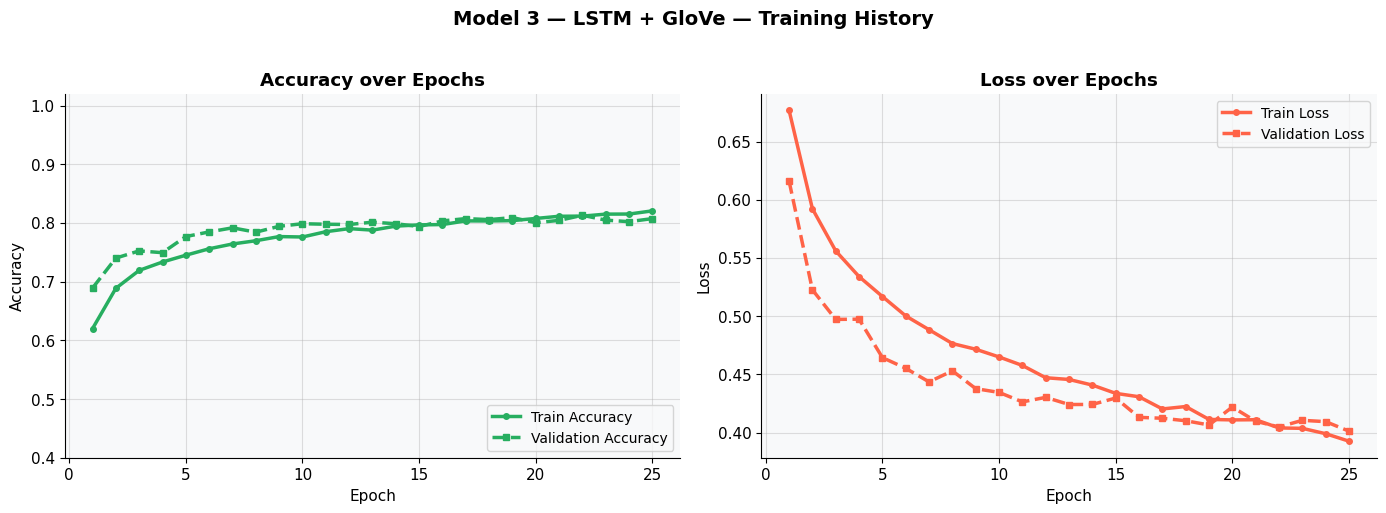


Model 3 — LSTM + GloVe
Test Accuracy : 0.8049  (80.49%)
Best Epoch    : 25
Train Acc @ best epoch: 0.8206
✅  Generalising well   — gap: 0.0158


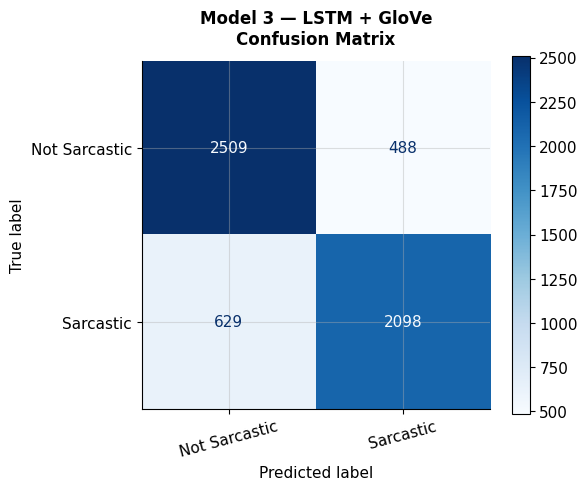


Classification Report:
               precision    recall  f1-score   support

Not Sarcastic     0.7996    0.8372    0.8179      2997
    Sarcastic     0.8113    0.7693    0.7898      2727

     accuracy                         0.8049      5724
    macro avg     0.8054    0.8033    0.8038      5724
 weighted avg     0.8051    0.8049    0.8045      5724



In [15]:
print('Loading GloVe Twitter 100-dim embeddings...')
print('(First run downloads ~200MB; cached on subsequent runs)')
glove_model   = api.load('glove-twitter-100')
embedding_dim = 100
print(f'GloVe loaded — vocabulary: {len(glove_model.key_to_index):,} words')

embedding_matrix = np.zeros((vocab_size + 1, embedding_dim))
for word, i in tokenizer.word_index.items():
    if word in glove_model:
        embedding_matrix[i] = glove_model[word]

covered = sum(1 for w in tokenizer.word_index if w in glove_model)
print(f'Embedding matrix shape : {embedding_matrix.shape}')
print(f'GloVe coverage         : {covered}/{vocab_size} ({covered/vocab_size*100:.1f}%)')

glove_lstm_model = Sequential([
    Input(shape=(max_len,)),

    Embedding(
        input_dim=vocab_size + 1,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        trainable=False
    ),

    Dropout(0.4),

    LSTM(64),

    BatchNormalization(),

    Dropout(0.5),

    Dense(32, activation='relu'),

    Dropout(0.3),

    Dense(1, activation='sigmoid')
], name='Model_3_LSTM_GloVe')

glove_lstm_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
glove_lstm_model.summary()

print('\nTraining Model 3 — LSTM + GloVe...')
t0 = time.time()

glove_history = glove_lstm_model.fit(
    X_train, y_train,
    epochs=25,
    batch_size=64,
    validation_split=0.1,
    callbacks=get_callbacks(),
    verbose=1
)

glove_time = (time.time() - t0) / 60
print(f'\nTraining Time : {glove_time:.1f} min')
print(f'Epochs run    : {len(glove_history.history["accuracy"])}')

plot_training_history(glove_history, 'Model 3 — LSTM + GloVe', color='#27ae60')

results['LSTM + GloVe'] = evaluate_model(
    glove_lstm_model, X_test, y_test,
    'Model 3 — LSTM + GloVe', glove_history
)


MODEL COMPARISON SUMMARY


,Model,Test Accuracy,Best Val Accuracy,Parameters,Epochs Run,Best Epoch,Train Time (min)
0,Simple RNN,0.7802,0.8031,"81,617",9,4,0.4
1,LSTM,0.7809,0.7948,"86,321",9,4,0.4
2,LSTM + GloVe,0.8049,0.8131,"2,301,709",25,25,1.3


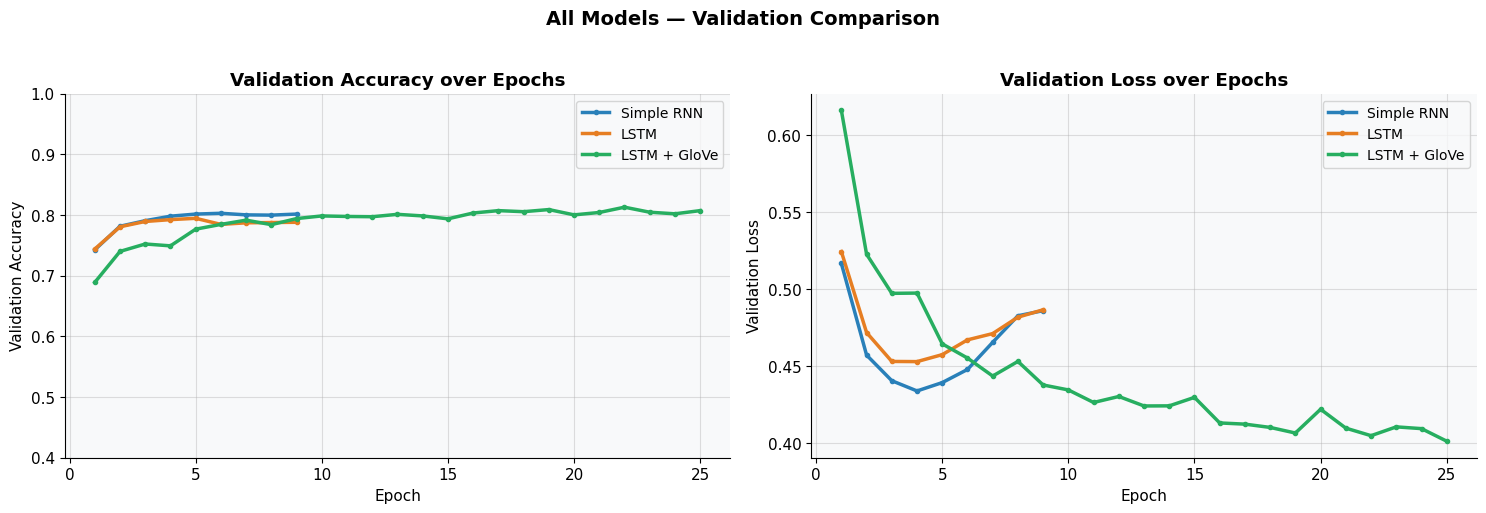

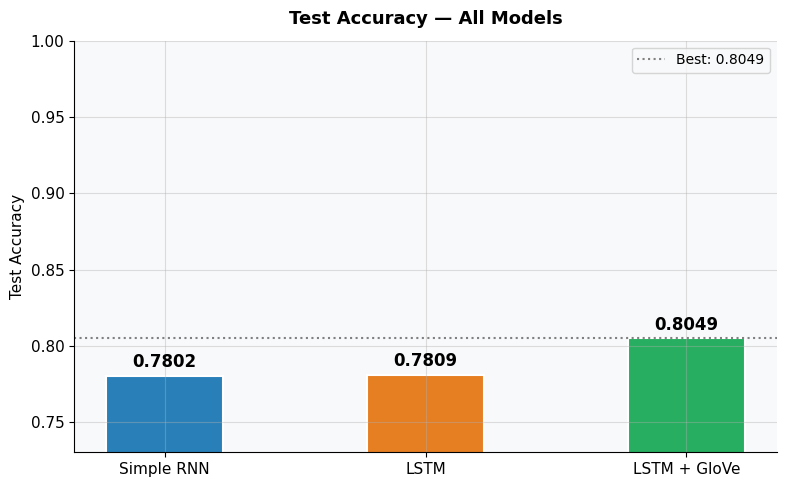

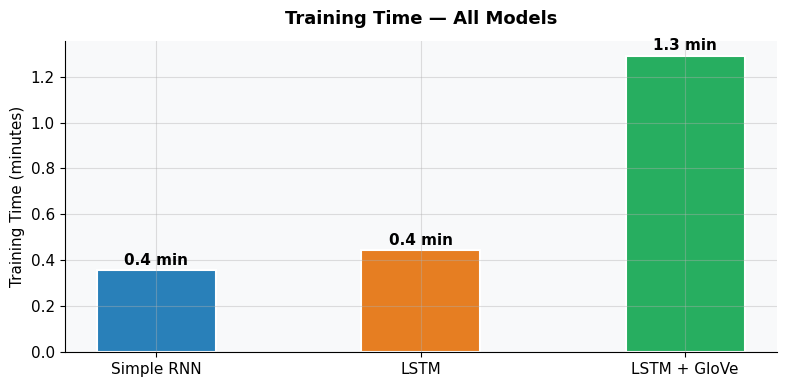


Best model : LSTM + GloVe
Test Acc   : 0.8049


In [16]:
# ── CELL 11: Comparative Analysis ────────────────────────────────────────────
# Compare all 3 models side-by-side on accuracy, loss, training time

model_objects = {
    'Simple RNN'  : (rnn_model,        rnn_history,   rnn_time),
    'LSTM'        : (lstm_model,        lstm_history,  lstm_time),
    'LSTM + GloVe': (glove_lstm_model,  glove_history, glove_time),
}

colors    = {'Simple RNN': '#2980b9', 'LSTM': '#e67e22', 'LSTM + GloVe': '#27ae60'}
histories = {'Simple RNN': rnn_history, 'LSTM': lstm_history, 'LSTM + GloVe': glove_history}

# ── Summary Table ─────────────────────────────────────────────────────────────
rows = []
for name, (model, history, t) in model_objects.items():
    best_ep = int(np.argmin(history.history['val_loss']))
    rows.append({
        'Model'           : name,
        'Test Accuracy'   : f"{results[name]['accuracy']:.4f}",
        'Best Val Accuracy': f"{max(history.history['val_accuracy']):.4f}",
        'Parameters'      : f"{model.count_params():,}",
        'Epochs Run'      : len(history.history['accuracy']),
        'Best Epoch'      : best_ep + 1,
        'Train Time (min)': f"{t:.1f}",
    })

comp_df = pd.DataFrame(rows)
print('\n' + '='*65)
print('MODEL COMPARISON SUMMARY')
print('='*65)
display(comp_df)

# ── Plot 1: Validation Accuracy — All Models Overlaid ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('All Models — Validation Comparison',
             fontsize=14, fontweight='bold', y=1.02)

for name, history in histories.items():
    ep = range(1, len(history.history['val_accuracy']) + 1)
    axes[0].plot(ep, history.history['val_accuracy'],
                 label=name, color=colors[name], lw=2.5, marker='o', markersize=3)
    axes[1].plot(ep, history.history['val_loss'],
                 label=name, color=colors[name], lw=2.5, marker='o', markersize=3)

axes[0].set_title('Validation Accuracy over Epochs', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Validation Accuracy')
axes[0].legend(fontsize=10)
axes[0].set_ylim(0.40, 1.00)

axes[1].set_title('Validation Loss over Epochs', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Validation Loss')
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.savefig('all_models_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Plot 2: Test Accuracy Bar Chart ──────────────────────────────────────────
model_names = list(results.keys())
accuracies  = [results[n]['accuracy'] for n in model_names]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(
    model_names, accuracies,
    color=[colors[n] for n in model_names],
    edgecolor='white', linewidth=1.5, width=0.45
)
for bar, acc in zip(bars, accuracies):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.003,
        f'{acc:.4f}', ha='center', va='bottom',
        fontsize=12, fontweight='bold'
    )
ax.set_title('Test Accuracy — All Models', fontsize=13, fontweight='bold', pad=12)
ax.set_ylabel('Test Accuracy')
ax.set_ylim(min(accuracies) - 0.05, 1.00)
ax.axhline(y=max(accuracies), color='gray', linestyle=':', lw=1.5,
            label=f'Best: {max(accuracies):.4f}')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('test_accuracy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Plot 3: Training Time Bar Chart ──────────────────────────────────────────
times = [rnn_time, lstm_time, glove_time]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(
    model_names, times,
    color=[colors[n] for n in model_names],
    edgecolor='white', linewidth=1.5, width=0.45
)
for bar, t in zip(bars, times):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f'{t:.1f} min', ha='center', va='bottom',
        fontsize=11, fontweight='bold'
    )
ax.set_title('Training Time — All Models', fontsize=13, fontweight='bold', pad=12)
ax.set_ylabel('Training Time (minutes)')
plt.tight_layout()
plt.savefig('training_time_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

best_model_name = max(results, key=lambda k: results[k]['accuracy'])
print(f'\nBest model : {best_model_name}')
print(f'Test Acc   : {results[best_model_name]["accuracy"]:.4f}')

In [17]:

best_model_name = max(results, key=lambda k: results[k]['accuracy'])
model_map = {
    'Simple RNN'  : rnn_model,
    'LSTM'        : lstm_model,
    'LSTM + GloVe': glove_lstm_model
}
print(f'Error analysis on best model: {best_model_name}')

y_pred       = results[best_model_name]['y_pred']
y_pred_prob  = results[best_model_name]['y_pred_prob']
lmap         = {0: 'Not Sarcastic', 1: 'Sarcastic'}

misclassified = np.where(y_pred != y_test)[0]
false_pos     = [i for i in misclassified if y_pred[i] == 1 and y_test[i] == 0]
false_neg     = [i for i in misclassified if y_pred[i] == 0 and y_test[i] == 1]

print(f'\nTotal misclassified : {len(misclassified)} / {len(y_test)} '
      f'({len(misclassified)/len(y_test)*100:.1f}%)')
print(f'False Positives (predicted Sarcastic, actually Not): {len(false_pos)}')
print(f'False Negatives (predicted Not Sarcastic, actually Sarcastic): {len(false_neg)}')

print('\n--- 3 False Positive Examples ---')
for i in false_pos[:3]:
    print(f'  Headline  : {X_test_raw[i]}')
    print(f'  True      : {lmap[y_test[i]]}  |  Predicted: {lmap[y_pred[i]]}')
    print(f'  Confidence: {y_pred_prob[i]:.4f}')
    print()

print('--- 3 False Negative Examples ---')
for i in false_neg[:3]:
    print(f'  Headline  : {X_test_raw[i]}')
    print(f'  True      : {lmap[y_test[i]]}  |  Predicted: {lmap[y_pred[i]]}')
    print(f'  Confidence: {y_pred_prob[i]:.4f}')
    print()

print('\n--- Model Complexity vs. Performance ---')
print(f'{"Model":<20} {"Parameters":>12} {"Test Acc":>10} {"Train Time":>12}')
print('-' * 58)
for name, (model, history, t) in model_objects.items():
    print(f'{name:<20} {model.count_params():>12,} '
          f'{results[name]["accuracy"]:>10.4f} {t:>10.1f}m')

print("""
=== Discussion: Why Errors Occur ===

1. False Positives — dramatic language in genuine news:
   Real headlines using emphatic words ("breakthrough", "shocking", "finally")
   resemble The Onion's exaggerated style. The model associates strong
   vocabulary with sarcasm incorrectly.

2. False Negatives — subtle sarcasm:
   Headlines like "Man successfully avoids eye contact on subway" are
   sarcastic because they treat a trivial event as an achievement.
   Individual tokens are neutral — the model cannot capture framing.

3. Ambiguity:
   Some headlines are inherently ambiguous even for humans.

=== Suggested Improvements ===

1. Bidirectional LSTM: processes sequences forward and backward,
   capturing setup + punchline structure of sarcastic headlines.

2. Attention mechanism: highlights the most sarcasm-relevant tokens.

3. BERT / Transformer: captures full bidirectional context simultaneously
   and encodes pragmatic world knowledge from massive corpora.

4. Larger dataset: more training examples reduces overfitting risk.
""")

Error analysis on best model: LSTM + GloVe

Total misclassified : 1117 / 5724 (19.5%)
False Positives (predicted Sarcastic, actually Not): 488
False Negatives (predicted Not Sarcastic, actually Sarcastic): 629

--- 3 False Positive Examples ---
  Headline  : mother special
  True      : Not Sarcastic  |  Predicted: Sarcastic
  Confidence: 0.5362

  Headline  : rex tillerson call report ouster laughable
  True      : Not Sarcastic  |  Predicted: Sarcastic
  Confidence: 0.7614

  Headline  : huckabee back denying abortion yearold raped stepfather
  True      : Not Sarcastic  |  Predicted: Sarcastic
  Confidence: 0.5604

--- 3 False Negative Examples ---
  Headline  : democratic congressman protest trump environmental policy bringing endangered red wolf state union guest
  True      : Sarcastic  |  Predicted: Not Sarcastic
  Confidence: 0.0593

  Headline  : prayer answered random series event cold uncaring universe
  True      : Sarcastic  |  Predicted: Not Sarcastic
  Confidence: 0.2001

In [19]:
best_model_name = max(results, key=lambda k: results[k]['accuracy'])
best_model      = model_map[best_model_name]
print(f'GUI powered by: {best_model_name}')


def predict_sarcasm(headline):
    """Preprocess headline and return prediction with confidence."""
    if not headline or not headline.strip():
        return 'Please enter a headline.'

    cleaned = preprocess_text(headline)
    seq     = tokenizer.texts_to_sequences([cleaned])
    padded  = pad_sequences(seq, maxlen=max_len, padding='post', truncating='post')
    prob    = best_model.predict(padded, verbose=0)[0][0]

    label      = 'Sarcastic' if prob >= 0.5 else 'Not Sarcastic'
    confidence = float(prob) if prob >= 0.5 else float(1 - prob)
    emoji      = '😏' if label == 'Sarcastic' else '📰'

    return (
        f"{emoji}  Prediction  : {label}\n"
        f"    Confidence  : {confidence*100:.1f}%\n"
        f"    Model used  : {best_model_name}"
    )


demo = gr.Interface(
    fn=predict_sarcasm,
    inputs=gr.Textbox(
        label='Enter a News Headline',
        placeholder='e.g. Area man heroically manages to get out of bed before noon',
        lines=2
    ),
    outputs=gr.Textbox(label='Prediction Result', lines=4),
    title='🗞️ Sarcasm Detector — News Headlines',
    description=(
        f'Powered by {best_model_name}. '
        'Trained on ~28,000 news headlines. '
        'Type any headline and click Submit.'
    ),
    examples=[
        ['Scientists discover that vegetables are healthy'],
        ['Area man heroically manages to get out of bed before noon'],
        ['New study confirms people enjoy being happy'],
        ['Global leaders meet to discuss climate action over luxury dinner'],
        ['Nation reports record number of people who just cannot even'],
    ],
    allow_flagging='never'
)

demo.launch(share=True)

GUI powered by: LSTM + GloVe
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://72155c41b1b26d83f6.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
